# Data Exploration

In [1]:
# Import
import os
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
from torchvision import datasets, transforms

In [2]:
# Setting seeds to reproduce 

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "neu_surface_defects" / "NEU-DET"

TRAIN_DIR = DATASET_ROOT / "train" / "images"
VAL_DIR   = DATASET_ROOT / "validation" / "images"

# Print statements to check the folders
# and the datasets exist boolean. 
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("TRAIN_DIR exists?:", TRAIN_DIR.exists())
print("VAL_DIR exists?:", VAL_DIR.exists())

PROJECT_ROOT: C:\Users\rphelps\OneDrive - Drexel University\CS-614-900\Assignments\Final Project\CS614-AI-Industrial-Quality-Inspector
DATASET_ROOT: C:\Users\rphelps\OneDrive - Drexel University\CS-614-900\Assignments\Final Project\CS614-AI-Industrial-Quality-Inspector\data\raw\neu_surface_defects\NEU-DET
TRAIN_DIR exists?: True
VAL_DIR exists?: True


In [3]:


basic_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(root=str(TRAIN_DIR), transform=basic_tfms)
val_ds   = datasets.ImageFolder(root=str(VAL_DIR), transform=basic_tfms)

print("Train images:", len(train_ds))
print("Val images:", len(val_ds))
print("Num classes:", len(train_ds.classes))
print("Classes:", train_ds.classes)
print("Same class mapping?", train_ds.class_to_idx == val_ds.class_to_idx)

Train images: 1440
Val images: 360
Num classes: 6
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Same class mapping? True


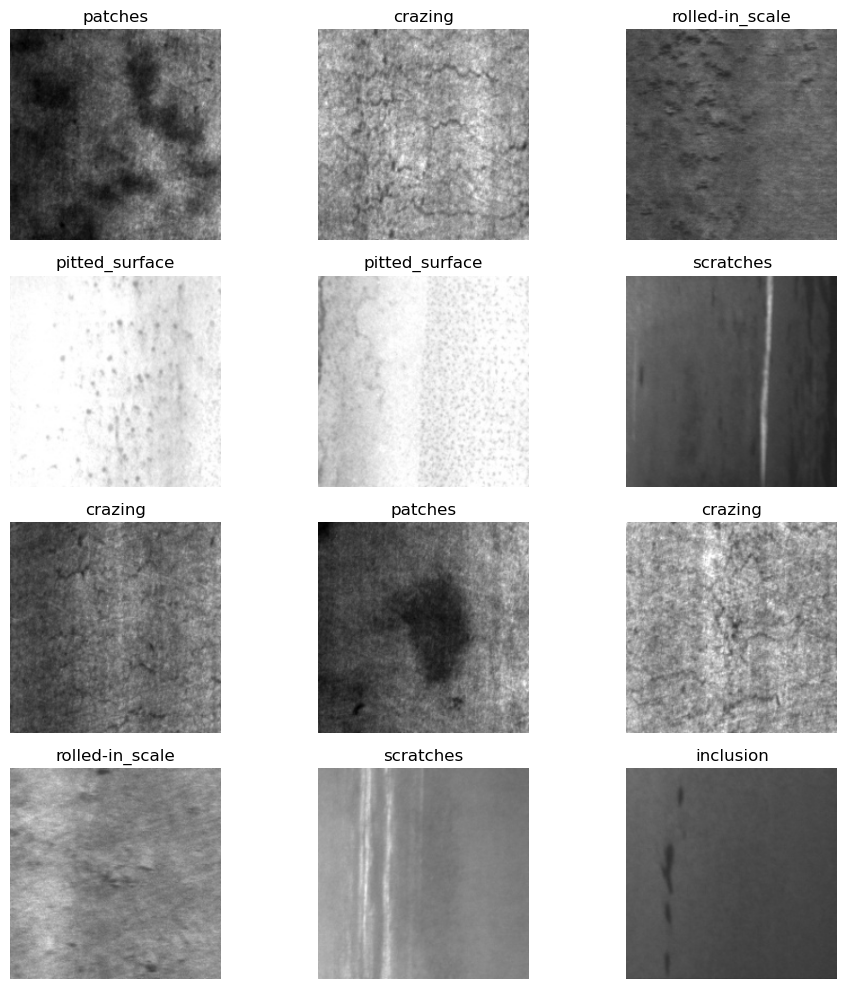

In [6]:


def show_samples(ds, n=12, seed=42):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=n, replace=False)

    cols = 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 10))

    for i, idx in enumerate(idxs, start=1):
        x, y = ds[idx]  # Tensor CHW, label index
        img = x.permute(1, 2, 0).numpy()  # CHW -> HWC
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(ds.classes[y])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=12)

Train counts:
         crazing: 240
       inclusion: 240
         patches: 240
  pitted_surface: 240
  rolled-in_scale: 240
       scratches: 240

Validation counts:
         crazing: 60
       inclusion: 60
         patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
       scratches: 60


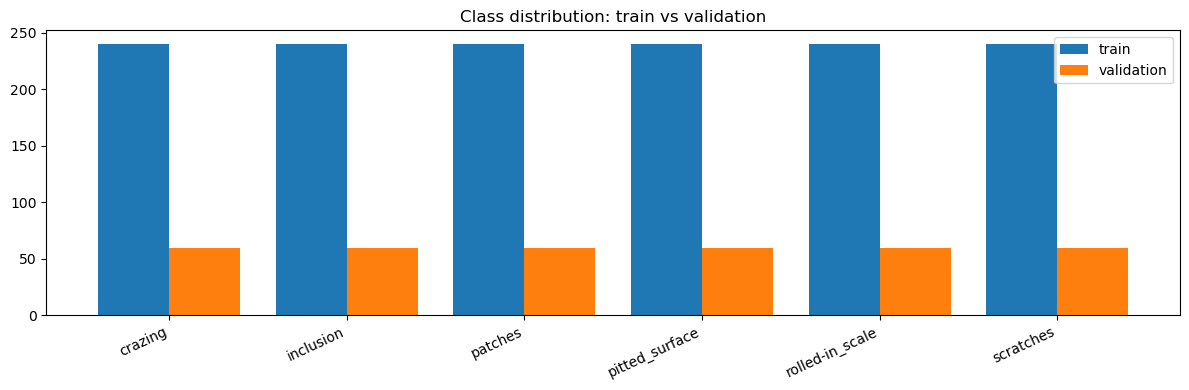

In [7]:


def class_counts(imagefolder_ds):
    targets = [y for _, y in imagefolder_ds.samples]
    counts = np.bincount(targets, minlength=len(imagefolder_ds.classes))
    return counts

train_counts = class_counts(train_ds)
val_counts   = class_counts(val_ds)

print("Train counts:")
for cls, cnt in zip(train_ds.classes, train_counts):
    print(f"  {cls:>14}: {cnt}")

print("\nValidation counts:")
for cls, cnt in zip(val_ds.classes, val_counts):
    print(f"  {cls:>14}: {cnt}")

# Plot side-by-side bars 
x = np.arange(len(train_ds.classes))
width = 0.4

plt.figure(figsize=(12,4))
plt.bar(x - width/2, train_counts, width, label="train")
plt.bar(x + width/2, val_counts, width, label="validation")
plt.xticks(x, train_ds.classes, rotation=25, ha="right")
plt.title("Class distribution: train vs validation")
plt.legend()
plt.tight_layout()
plt.show()